In [35]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle

from collections import defaultdict




In [65]:
# import funcs

%run ./utils.ipynb
%run ./utilsMassProfile.ipynb

In [3]:
Myr_per_Nbody = 0.36627254517014160E+03/ 0.15200000000000000E+03
source = '/cosma5/data/durham/dc-pick2/simulations'
hyades = source + '/Hyades'
hyades

'/cosma5/data/durham/dc-pick2/simulations/Hyades'

In [4]:
path = hyades + '/snap.40_240.h5part'
path

'/cosma5/data/durham/dc-pick2/simulations/Hyades/snap.40_240.h5part'

In [5]:
with h5py.File(path, 'r') as f:
        last_step = list(f.keys())[-1]
        x = f[last_step]['X1'][:]
        y = f[last_step]['X2'][:]
        z = f[last_step]['X3'][:]
        m = f[last_step]['M'][:]
        t = f[last_step].attrs['Time'] * Myr_per_Nbody

        mtot = np.sum(m)



In [6]:
get_com(x, y, z, m)

[np.float32(15.102393), np.float32(-7.5536737), np.float32(0.4713251)]

In [7]:
history = []
com = shrinking_sphere(x, y, z, m, history=history)

history = np.asarray(history)
history

array([[-1032.8811   ,   536.35803  ,    -9.94536  ],
       [-1033.0524   ,   535.5154   ,   -13.261286 ],
       [-1032.9248   ,   535.4217   ,   -13.173609 ],
       [-1032.9133   ,   535.31744  ,   -13.030437 ],
       [-1032.9125   ,   535.28235  ,   -12.581894 ],
       [-1033.1149   ,   535.39075  ,   -12.007958 ],
       [-1033.4073   ,   535.2103   ,   -11.395536 ],
       [-1033.3849   ,   535.27826  ,   -11.15978  ],
       [-1033.2651   ,   535.18256  ,   -10.943662 ],
       [-1033.2515   ,   535.1563   ,   -10.763935 ],
       [-1033.4396   ,   535.2703   ,   -10.513704 ],
       [-1033.6725   ,   535.47656  ,   -10.30563  ],
       [-1033.7566   ,   535.55634  ,   -10.127041 ],
       [-1033.7899   ,   535.5774   ,    -9.852741 ],
       [-1033.7423   ,   535.6365   ,    -9.715851 ],
       [-1033.604    ,   535.5576   ,    -9.61242  ],
       [-1033.5491   ,   535.6496   ,    -9.530256 ],
       [-1033.3627   ,   535.6416   ,    -9.426329 ],
       [-1033.3033   ,   535

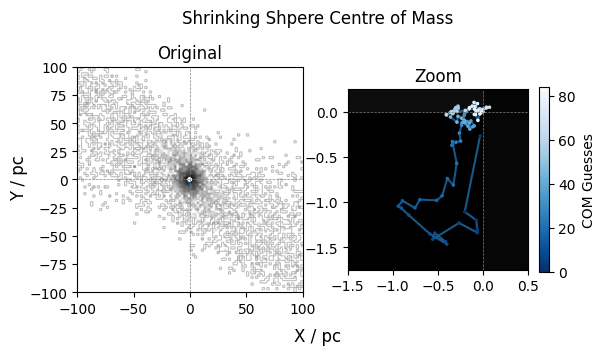

In [8]:
offset = 100
zoom_offset = 1

fig, ax = plt.subplots(1,2)

hist, xedges, yedges = np.histogram2d(x - com[0], y - com[1], bins=100, range=[[-offset, offset], [-offset, offset]])
ax[0].imshow(
hist.T,
origin='lower',
extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
cmap='gray_r',
norm=LogNorm()
)
hist, xedges, yedges = np.histogram2d(x - com[0], y - com[1], bins=100, range=[[-offset, offset], [-offset, offset]])
ax[1].imshow(
hist.T,
origin='lower',
extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
cmap='gray_r',
norm=LogNorm()
)


histx = history.T[0]
histy = history.T[1]

ax[0].plot(histx - com[0], histy - com[1], color='tab:blue', alpha=0.75)
ax[1].plot(histx - com[0], histy - com[1], color='tab:blue', alpha=0.75)

ax[0].scatter(histx - com[0], histy - com[1], label='guesses', marker='.',
                c=range(len(history)), cmap='Blues_r', s=10, zorder=2)
cb = ax[1].scatter(histx - com[0], histy - com[1], label='COM guesses', marker='.',
                c=range(len(history)), cmap='Blues_r', s=10, zorder=2)

plt.colorbar(cb, ax=ax[1], shrink=0.5, label='COM Guesses')


ax[0].set_xlim(-offset, offset)
ax[0].set_ylim(- offset, offset)
ax[0].set_aspect('equal')
ax[0].set_title('Original')


ax[1].set_xlim(-zoom_offset-0.5, zoom_offset-0.5)
ax[1].set_ylim(- zoom_offset-0.75, zoom_offset-0.75)
ax[1].set_aspect('equal')
ax[1].set_title('Zoom')

ax[0].axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax[0].axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax[1].axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax[1].axvline(0, color='gray', linewidth=0.5, linestyle='--')

fig.supxlabel('X / pc', y=0.15)
fig.supylabel('Y / pc')

fig.suptitle('Shrinking Shpere Centre of Mass', y=0.85)

plt.savefig('Images/ShrinkShereCOM.png')
plt.show()

In [9]:
fractions = np.asarray([0.75, 0.5, 0.25])
frac_mass_radii = find_bounding_radii(x, y, z, m, fractions)
frac_mass_radii

array([99.99002  , 28.555422 ,  7.4819603], dtype=float32)

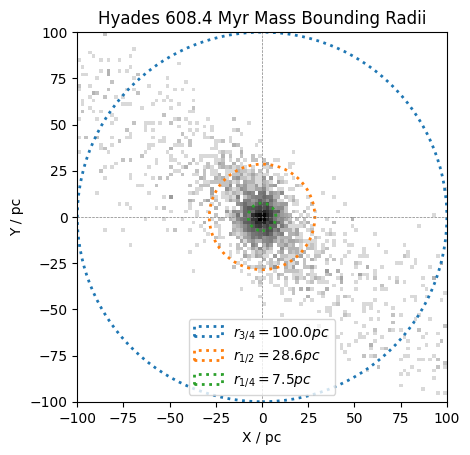

In [10]:
offset = 100
frac_lables = ['3/4', '1/2', '1/4']
lables = [fr'$r_{{{l}}}={v:.1f}pc$' for l, v in zip(frac_lables, frac_mass_radii)]
          
colours = ['tab:blue', 'tab:orange', 'tab:green']

fig, ax = plt.subplots()

hist, xedges, yedges = np.histogram2d(x - com[0], y - com[1], bins=100, 
                                      range=[[-offset, offset], [-offset, offset]])
ax.imshow(
hist.T,
origin='lower',
extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
cmap='gray_r',
norm=LogNorm()
)

for r, label, colour in zip(frac_mass_radii, lables, colours):
    r_mass_radius = Circle((0,0), r, fill=False, linestyle='dotted',
                           color=colour, label=label, linewidth=2)
    ax.add_artist(r_mass_radius)



ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_title(f'Hyades {t:.1f} Myr Mass Bounding Radii')
ax.set_xlabel('X / pc')
ax.set_ylabel('Y / pc')
ax.set_xlim(-offset, offset)
ax.set_ylim(- offset, offset)
ax.set_aspect('equal')
plt.legend()

plt.show()


In [11]:
fractions = np.asarray([0.75, 0.5, 0.25])
results = []
times = []

for snap in [0, 60, 120, 180, 240]:
    path = hyades + f'/snap.40_{snap}.h5part'

    with h5py.File(path, 'r') as f:
        last_step = list(f.keys())[-1]
        x = f[last_step]['X1'][:]
        y = f[last_step]['X2'][:]
        z = f[last_step]['X3'][:]
        m = f[last_step]['M'][:]
        t = f[last_step].attrs['Time'] * Myr_per_Nbody

        frac_mass_radii = find_bounding_radii(x, y, z, m, fractions)
        results.append(frac_mass_radii)
        times.append(t)

    
results = np.asarray(results)
times = np.asarray(times)




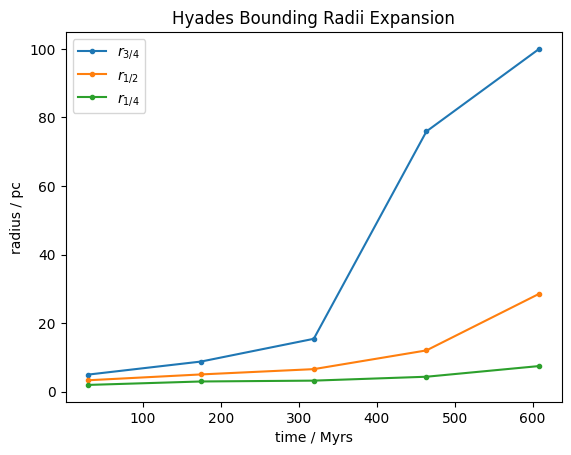

In [12]:
frac_lables = ['3/4', '1/2', '1/4']
lables = [fr'$r_{{{l}}}$' for l in frac_lables]

fig, ax = plt.subplots()

for i, (label, colour) in enumerate(zip(lables, colours)):
    ax.plot(times, results.T[i], label=label, color=colour, marker='.')

ax.set_xlabel('time / Myrs')
ax.set_ylabel('radius / pc')

#ax.set_yscale('log')

plt.title("Hyades Bounding Radii Expansion")
plt.legend()
plt.show()
 

In [13]:
results.T[0]

array([ 4.993082,  8.79833 , 15.429023, 75.92934 , 99.99002 ],
      dtype=float32)

In [46]:
times = [0,100,200,300,400,500]

data, glob_df, Myr_per_Nbody = get_steps_at_times(hyades, times)


mass_profiles = find_mass_profiles(data)


/tmp/ipykernel_3459190/3720612914.py:25: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  return pd.read_csv(glob_path, sep=r"\s+", index_col=False)


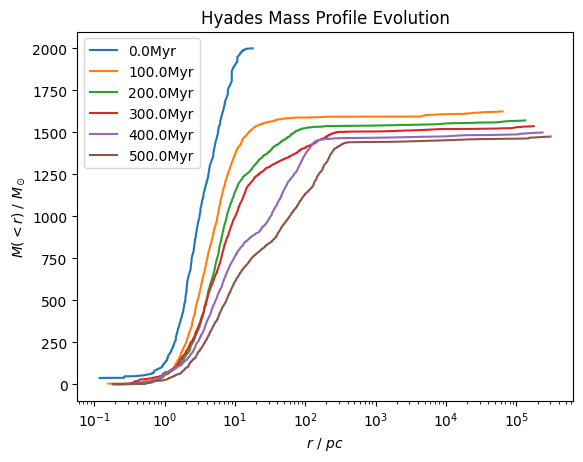

In [58]:
fig, ax = plt.subplots()
plot_mass_profile(fig, ax, mass_profiles, title='Hyades Mass Profile Evolution')
plt.show()

In [87]:
times = np.logspace(np.log10(1), np.log10(600), num=20)
experiment_path = source + '/Concentration'

runs_data = get_runs_data(experiment_path, times)

runs_mass_profiles = find_mass_profiles_experiment(runs_data)

/tmp/ipykernel_3459190/3720612914.py:25: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  return pd.read_csv(glob_path, sep=r"\s+", index_col=False)
/tmp/ipykernel_3459190/3720612914.py:25: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  return pd.read_csv(glob_path, sep=r"\s+", index_col=False)
/tmp/ipykernel_3459190/3720612914.py:25: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  return pd.read_csv(glob_path, sep=r"\s+", index_col=False)
/tmp/ipykernel_3459190/3720612914.py:25: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  return pd.read_csv(glob_path, sep=r"\s+", index_col=False)
/tmp/ipykernel_3459190/3720612914.py:25: ParserWarning: Length of header or names does not match len

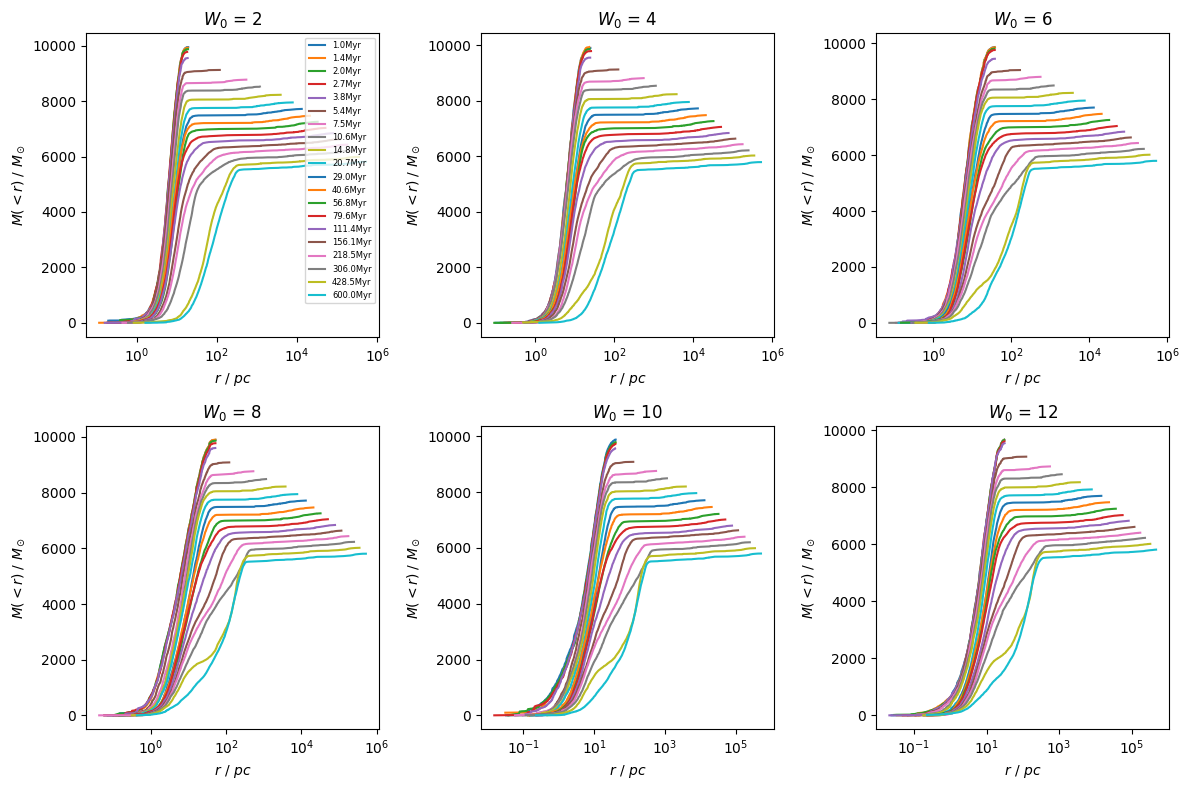

In [88]:
ncols = 3
nrows = int(np.ceil(len(runs_data) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4*nrows))

plot_mass_profiles(fig, axes, runs_mass_profiles, titlehead=r'$W_0$ = ')

axes[0][0].legend(fontsize=6)
plt.tight_layout()
plt.show()